Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 16, 4)          │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 8, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 8, 4)           │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 4, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 4, 4)           │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 2, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 4, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 4, 4)           │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 8, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 8, 2)           │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_2 (UpSampling1D)  │ (None, 16, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 16, 1)          │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1439/1439 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0012 - val_loss: 2.3823e-05
Epoch 2/200
1439/1439 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 2.7223e-06 - val_loss: 3.1946e-06
Epoch 3/200
1439/1439 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 4.8099e-07 - val_loss: 9.3183e-07
Epoch 4/200
1439/1439 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.3147e-07 - val_loss: 5.0273e-07
Epoch 5/200
1439/1439 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.6946e-08 - val_loss: 4.1808e-07
Epoch 6/200
1439/1439 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.8849e-08 - val_loss: 3.7240e-07
Epoch 7/200
1439/1439 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 9.2493e-09 - val_loss: 2.1389e-07
Epoch 8/200
1439/1439 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 2.7910e-09 - val_loss: 2.8072e-07
Epoch 9/200
1439/1439 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.6180e-11 - val_loss: 2.7571e-07
Epoch 10/200
1439/1439 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 4.1625e-10 - val_loss: 2.7115e-07
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6m

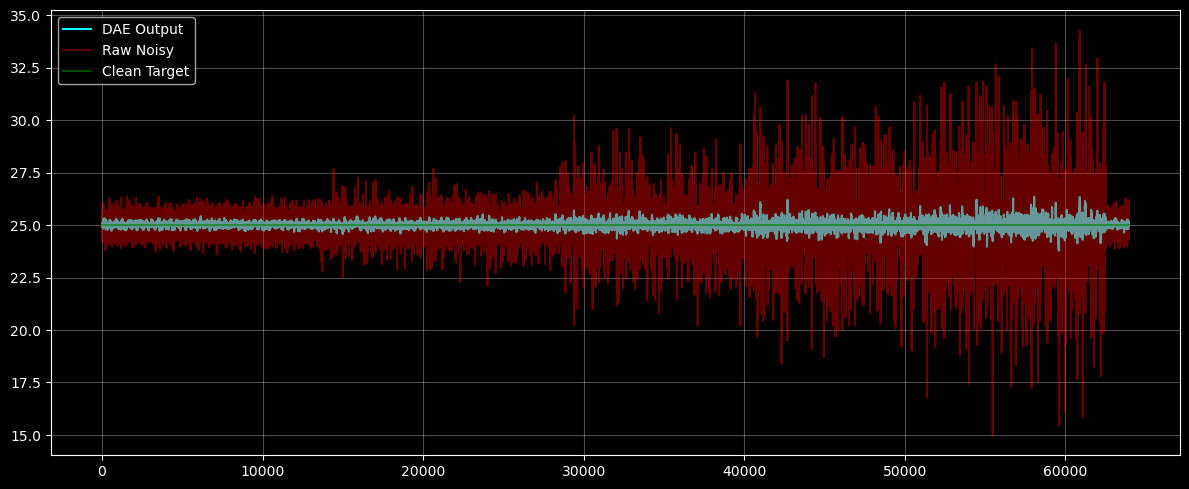

In [1]:

import tensorflow as tf
from tensorflow.keras import layers, Model

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


SEED = 1000
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

WIN = 16   # window length


df = pd.read_excel("Book5.xlsx", engine="openpyxl")

Sample1     = df["Sample1"].values.astype(np.float32)
Sample2     = df["Sample2"].values.astype(np.float32)
clean1      = df["clean1"].values.astype(np.float32)
Sample2Off  = df["Sample2Off"].values.astype(np.float32)
clean3      = df["clean3"].values.astype(np.float32)


Sample2_train, Sample2_test = train_test_split(Sample2Off, test_size=0.20, shuffle=False)

noisy_train, noisy_test, clean_train, clean_test = train_test_split(
    Sample2, clean1, test_size=0.20, shuffle=False
)


def preprocess_window(w):
    dc = np.mean(w)
    w0 = w - dc
    return w0, dc


def make_windows_seq(noisy, clean, N, training=True):
    X, Y = [], []
    DCs = []

    for i in range(len(noisy) - N + 1):
        w_noisy = noisy[i:i+N].astype(np.float32)
        w_clean = clean[i:i+N].astype(np.float32)

       
        if training:
            dc_aug = np.random.uniform(-5, 5)
            w_noisy = w_noisy + dc_aug - dc_aug
            w_clean = w_clean + dc_aug - dc_aug

     
        w_proc, dc = preprocess_window(w_noisy)

       
        clean_zm = w_clean - np.mean(w_clean)

        X.append(w_proc)
        Y.append(clean_zm)
        DCs.append(dc)

    X = np.array(X).reshape(-1, N, 1)
    Y = np.array(Y).reshape(-1, N, 1)
    DCs = np.array(DCs).reshape(-1, 1)

    return X, Y, DCs


X_train, Y_train, DC_train = make_windows_seq(noisy_train, clean_train, WIN, training=True)
X_test,  Y_test,  DC_test  = make_windows_seq(noisy_test,  clean_test,  WIN, training=False)


def build_dae(input_length, channels=1):
    inp = layers.Input(shape=(input_length, channels))


    x = layers.Conv1D(4, 4, padding='same', activation='relu')(inp)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(4, 4, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Conv1D(4, 4, padding='same', activation='relu')(x)
    encoded = layers.MaxPooling1D(2)(x)

  
    x = layers.UpSampling1D(2)(encoded)
    x = layers.Conv1D(4, 4, padding='same', activation='relu')(x)

    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(2, 4, padding='same', activation='relu')(x)

    x = layers.UpSampling1D(2)(x)
    decoded = layers.Conv1D(channels, 4, padding='same', activation='linear')(x)

    return Model(inp, decoded)

model = build_dae(WIN, channels=1)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
model.summary()

callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)


history = model.fit(
    X_train, Y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[callback],
    verbose=1
)


X_full, _, DC_full = make_windows_seq(
    Sample2Off, Sample2Off, WIN, training=False
)

y_hat_full = model.predict(X_full, batch_size=1024)


y_hat_full = y_hat_full + DC_full[:, None, :]


y_hat_full = y_hat_full[:, WIN//2, 0]


offset = WIN//2
noisy_aligned = Sample2Off[offset:offset+len(y_hat_full)]
clean_aligned = clean3[offset:offset+len(y_hat_full)]


plt.style.use('dark_background')
plt.figure(figsize=(12,5))

plt.plot(y_hat_full, label="DAE Output", color='cyan')
plt.plot(Sample2Off[:len(y_hat_full)], label="Raw Noisy", color='red', alpha=0.4)
plt.plot(clean3[:len(y_hat_full)], label="Clean Target", color='green', alpha=0.6)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
